# TP Analyse de Données — Olist E-Commerce
## Partie 1 — Chargement & Exploration des Données
### 1.1 — Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

BASE = r'C:\Users\HP\Desktop\projet_dataAnalyse\Data\raw' + '\\'

orders     = pd.read_csv(BASE + 'olist_orders_dataset.csv')
items      = pd.read_csv(BASE + 'olist_order_items_dataset.csv')
products   = pd.read_csv(BASE + 'olist_products_dataset.csv')
customers  = pd.read_csv(BASE + 'olist_customers_dataset.csv')
reviews    = pd.read_csv(BASE + 'olist_order_reviews_dataset.csv')
sellers    = pd.read_csv(BASE + 'olist_sellers_dataset.csv')
payments   = pd.read_csv(BASE + 'olist_order_payments_dataset.csv')
categories = pd.read_csv(BASE + 'product_category_name_translation.csv')

print("✅ Tous les fichiers chargés avec succès !")

✅ Tous les fichiers chargés avec succès !


In [2]:
# Question 1 — Dimensions et aperçu de chaque DataFrame
dfs = {
    'orders': orders, 
    'items': items, 
    'products': products,
    'customers': customers, 
    'reviews': reviews,
    'sellers': sellers, 
    'payments': payments, 
    'categories': categories
}

for name, df in dfs.items():
    print(f"\n{'='*45}")
    print(f"📋 {name.upper()} — {df.shape[0]} lignes, {df.shape[1]} colonnes")
    print(f"{'='*45}")
    display(df.head(3))


📋 ORDERS — 99441 lignes, 8 colonnes


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



📋 ITEMS — 112650 lignes, 7 colonnes


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



📋 PRODUCTS — 32951 lignes, 9 colonnes


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



📋 PAYMENTS — 103886 lignes, 5 colonnes


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71



📋 CATEGORIES — 71 lignes, 2 colonnes


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


### Réponse Question 1
Le dataset Olist contient 8 tables reliées entre elles.
La table principale `orders` contient 99 441 commandes.
La table `items` contient 112 650 lignes car une commande
peut contenir plusieurs articles.

In [3]:
# Question 2 — Types des colonnes
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


### Réponse Question 2 — Types des colonnes de dates

Les colonnes de dates (`order_purchase_timestamp`, `order_approved_at`,
`order_delivered_carrier_date`, `order_delivered_customer_date`,
`order_estimated_delivery_date`) sont toutes de type `object` (chaîne 
de caractères) après le chargement.

Ce type n'est pas correct car il ne permet pas de faire des calculs 
temporels comme la différence entre deux dates.
Il faudra les convertir en `datetime64` avec `pd.to_datetime()` 
en Partie 2.

In [4]:
# Question 3 — Valeurs manquantes par DataFrame
def missing_report(df, name):
    pct = round(df.isna().sum() / len(df) * 100, 2)
    pct = pct[pct > 0].sort_values(ascending=False)
    print(f'\n--- {name} ---')
    print(pct if len(pct) else 'Aucune valeur manquante ✅')

for name, df in dfs.items():
    missing_report(df, name)


--- orders ---
order_delivered_customer_date    2.98
order_delivered_carrier_date     1.79
order_approved_at                0.16
dtype: float64

--- items ---
Aucune valeur manquante ✅

--- products ---
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64

--- customers ---
Aucune valeur manquante ✅

--- reviews ---
review_comment_title      88.34
review_comment_message    58.70
dtype: float64

--- sellers ---
Aucune valeur manquante ✅

--- payments ---
Aucune valeur manquante ✅

--- categories ---
Aucune valeur manquante ✅


### Réponse Question 3 — Valeurs manquantes

Les colonnes avec le plus de valeurs manquantes sont :

- `review_comment_title` (88.34%) et `review_comment_message` (58.70%) 
  dans la table reviews : cela est logique car les clients ne sont pas 
  obligés de rédiger un commentaire, ils peuvent juste donner une note.

- `order_delivered_customer_date` (2.98%) dans orders : ces commandes 
  n'ont pas encore été livrées au moment de l'extraction des données.

- `product_category_name` (1.85%) dans products : certains produits 
  n'ont pas de catégorie renseignée dans le catalogue.

Ces valeurs manquantes seront traitées en Partie 2 lors du nettoyage.

       order_item_id          price  freight_value
count  112650.000000  112650.000000  112650.000000
mean        1.197834     120.653739      19.990320
std         0.705124     183.633928      15.806405
min         1.000000       0.850000       0.000000
25%         1.000000      39.900000      13.080000
50%         1.000000      74.990000      16.260000
75%         1.000000     134.900000      21.150000
max        21.000000    6735.000000     409.680000


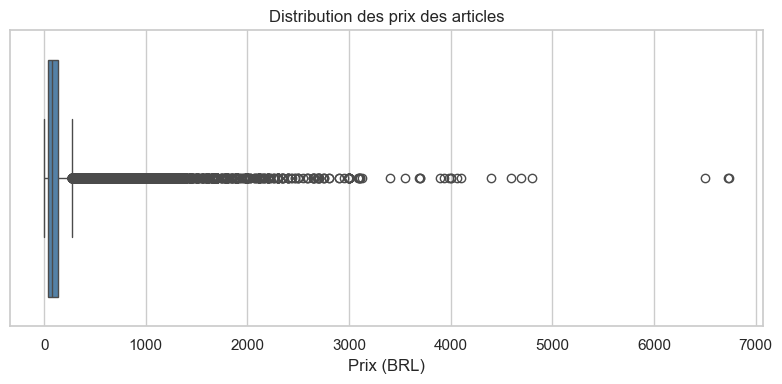

In [5]:
# Question 4 — Statistiques descriptives sur items
print(items.describe())

# Boxplot du prix
plt.figure(figsize=(8, 4))
sns.boxplot(x=items['price'], color='steelblue')
plt.title('Distribution des prix des articles')
plt.xlabel('Prix (BRL)')
plt.tight_layout()
plt.savefig(r'C:\Users\HP\Desktop\projet_dataAnalyse\visuals\boxplot_prix.png', dpi=150)
plt.show()

### Réponse Question 4 — Statistiques sur le prix

Le prix moyen d'un article est de 120.65 BRL, mais la médiane est 
de seulement 74.99 BRL. Cet écart important indique la présence de 
valeurs aberrantes (outliers).

En effet, le prix maximum atteint 6 735 BRL et l'écart-type est 
très élevé (183.63), ce qui confirme une distribution très asymétrique.
La médiane est donc plus représentative que la moyenne pour décrire 
le prix typique d'un article.

## Partie 2 — Nettoyage, Feature Engineering & Fusion

### 2.1 — Suppression des colonnes inutiles

In [6]:
# Suppression des colonnes inutiles
orders    = orders.drop(columns=['order_approved_at', 
                                  'order_delivered_carrier_date'])

items     = items.drop(columns=['order_item_id', 
                                 'shipping_limit_date'])

products  = products.drop(columns=['product_name_lenght',
                                    'product_description_lenght',
                                    'product_photos_qty',
                                    'product_length_cm',
                                    'product_height_cm',
                                    'product_width_cm'])

customers = customers.drop(columns=['customer_unique_id',
                                     'customer_zip_code_prefix'])

reviews   = reviews.drop(columns=['review_id',
                                   'review_comment_title',
                                   'review_comment_message',
                                   'review_creation_date',
                                   'review_answer_timestamp'])

sellers   = sellers.drop(columns=['seller_zip_code_prefix'])

payments  = payments.drop(columns=['payment_sequential'])

# Vérification
for name, df in dfs.items():
    print(f"{name} → {df.shape[1]} colonnes restantes")

orders → 8 colonnes restantes
items → 7 colonnes restantes
products → 9 colonnes restantes
customers → 5 colonnes restantes
reviews → 7 colonnes restantes
sellers → 4 colonnes restantes
payments → 5 colonnes restantes
categories → 2 colonnes restantes


In [7]:
# Recréer le dictionnaire APRÈS les suppressions
dfs = {
    'orders': orders, 
    'items': items, 
    'products': products,
    'customers': customers, 
    'reviews': reviews,
    'sellers': sellers, 
    'payments': payments, 
    'categories': categories
}

# Vérification
for name, df in dfs.items():
    print(f"{name} → {df.shape[1]} colonnes restantes")

orders → 6 colonnes restantes
items → 5 colonnes restantes
products → 3 colonnes restantes
customers → 3 colonnes restantes
reviews → 2 colonnes restantes
sellers → 3 colonnes restantes
payments → 4 colonnes restantes
categories → 2 colonnes restantes


### 2.2 — Conversion des types temporels

In [8]:
# Conversion des colonnes de dates en datetime64
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

orders[date_cols] = orders[date_cols].apply(pd.to_datetime)

# Vérification
print(orders.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


### 2.3 — Calcul des délais de livraison

In [9]:
# Calcul du délai de livraison en jours
orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days

# Calcul du retard (positif = en retard, négatif = en avance)
orders['delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.days

# Vérification
print(orders[['order_purchase_timestamp',
              'order_delivered_customer_date',
              'delivery_days',
              'delay_days']].head())

  order_purchase_timestamp order_delivered_customer_date  delivery_days  \
0      2017-10-02 10:56:33           2017-10-10 21:25:13            8.0   
1      2018-07-24 20:41:37           2018-08-07 15:27:45           13.0   
2      2018-08-08 08:38:49           2018-08-17 18:06:29            9.0   
3      2017-11-18 19:28:06           2017-12-02 00:28:42           13.0   
4      2018-02-13 21:18:39           2018-02-16 18:17:02            2.0   

   delay_days  
0        -8.0  
1        -6.0  
2       -18.0  
3       -13.0  
4       -10.0  


In [10]:
# Question 5 — Médiane et % de retard
mediane = orders['delivery_days'].median()
pct_retard = (orders['delay_days'] > 0).sum() / orders['delay_days'].notna().sum() * 100

print(f"📦 Médiane du délai de livraison : {mediane} jours")
print(f"⏰ Commandes livrées en retard : {pct_retard:.2f}%")

📦 Médiane du délai de livraison : 10.0 jours
⏰ Commandes livrées en retard : 6.77%


### Réponse Question 5 — Délais de livraison

La médiane du délai de livraison est de 10 jours, ce qui signifie 
que la moitié des commandes sont livrées en moins de 10 jours.

Seulement 6.77% des commandes sont livrées en retard par rapport 
à la date estimée. Cela indique qu'Olist respecte globalement bien 
ses engagements de livraison.

### 2.4 — Fusion des tables (merge)

In [11]:
# Étape 1 : commandes + articles
df = orders.merge(items, on='order_id', how='inner')
print(f'Après orders+items : {df.shape}')

# Étape 2 : + produits avec traduction catégorie
products = products.merge(categories, on='product_category_name', how='left')
df = df.merge(products[['product_id',
                         'product_category_name_english',
                         'product_weight_g']],
              on='product_id', how='inner')
print(f'Après +products : {df.shape}')

# Étape 3 : + vendeurs
df = df.merge(sellers[['seller_id','seller_state']], 
              on='seller_id', how='inner')
print(f'Après +sellers : {df.shape}')

# Étape 4 : + clients
df = df.merge(customers[['customer_id',
                          'customer_state',
                          'customer_city']],
              on='customer_id', how='left')
print(f'Après +customers : {df.shape}')

# Étape 5 : + avis clients
df = df.merge(reviews[['order_id','review_score']], 
              on='order_id', how='left')
print(f'Après +reviews : {df.shape}')

display(df.head(3))

Après orders+items : (112650, 12)
Après +products : (112650, 14)
Après +sellers : (112650, 15)
Après +customers : (112650, 17)
Après +reviews : (113314, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,product_id,seller_id,price,freight_value,product_category_name_english,product_weight_g,seller_state,customer_state,customer_city,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,housewares,500.0,SP,SP,sao paulo,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumery,400.0,SP,BA,barreiras,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,auto,420.0,SP,GO,vianopolis,5.0


### Réponse Question 6 — Nombre de lignes après fusion

Le DataFrame final contient 113 314 lignes, ce qui est supérieur 
au nombre de commandes initiales (99 441). Cela s'explique par le fait 
qu'une commande peut contenir plusieurs articles — la table items 
avait déjà 112 650 lignes. De plus, certaines commandes ont plusieurs 
avis clients, ce qui peut encore augmenter le nombre de lignes.

### Réponse Question 7 — Valeurs manquantes résiduelles

In [12]:
# Question 7 — Valeurs manquantes dans df final
print("Valeurs manquantes dans df :")
manquants = df.isna().sum()
manquants = manquants[manquants > 0]
print(manquants)
print(f"\nTotal lignes : {len(df)}")

Valeurs manquantes dans df :
order_delivered_customer_date    2475
delivery_days                    2475
delay_days                       2475
product_category_name_english    1636
product_weight_g                   18
review_score                      942
dtype: int64

Total lignes : 113314


### Réponse Question 7 — Traitement des valeurs manquantes

Après la fusion, plusieurs colonnes présentent des valeurs manquantes :

- `order_delivered_customer_date`, `delivery_days`, `delay_days` 
  (2 475 lignes) : ce sont des commandes non encore livrées. 
  On les ignore car elles ne peuvent pas être analysées pour les délais.

- `product_category_name_english` (1 636 lignes) : certains produits 
  n'ont pas de traduction de catégorie. On les ignorera lors des 
  analyses par catégorie (dropna au moment du groupby).

- `product_weight_g` (18 lignes) : très peu de valeurs manquantes, 
  on peut les ignorer sans impact sur l'analyse.

- `review_score` (942 lignes) : certaines commandes n'ont pas reçu 
  d'avis client. On les ignorera lors des analyses de satisfaction 
  (dropna au moment du groupby).

Choix global : on ne supprime pas ces lignes maintenant pour ne pas 
perdre d'information. On appliquera dropna uniquement lors des 
analyses concernées.

## Partie 3 — Analyse Descriptive & Agrégations

### 3.1 — Évolution du chiffre d'affaires mensuel

In [13]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
print(df['month'].head())

0    2017-10
1    2018-07
2    2018-08
3    2017-11
4    2018-02
Name: month, dtype: object


In [14]:
print(df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'delay_days', 'product_id', 'seller_id', 'price', 'freight_value', 'product_category_name_english', 'product_weight_g', 'seller_state', 'customer_state', 'customer_city', 'review_score', 'month']


In [15]:
ca_mensuel = (
    df.groupby('month')
    .agg(ca_total=('price', 'sum'), 
         nb_commandes=('order_id', 'nunique'))
    .reset_index()
)

print(ca_mensuel)

      month    ca_total  nb_commandes
0   2016-09      267.36             3
1   2016-10    49634.35           308
2   2016-12       10.90             1
3   2017-01   121087.90           789
4   2017-02   248563.02          1733
5   2017-03   376010.70          2641
6   2017-04   360738.17          2391
7   2017-05   509639.63          3660
8   2017-06   436550.89          3217
9   2017-07   501299.70          3969
10  2017-08   578588.99          4293
11  2017-09   626752.17          4243
12  2017-10   667869.15          4568
13  2017-11  1017758.83          7451
14  2017-12   746717.15          5624
15  2018-01   955658.74          7220
16  2018-02   853591.21          6694
17  2018-03   986867.05          7188
18  2018-04   998893.07          6934
19  2018-05   997066.66          6853
20  2018-06   865956.24          6160
21  2018-07   897496.14          6273
22  2018-08   854760.45          6452
23  2018-09      145.00             1


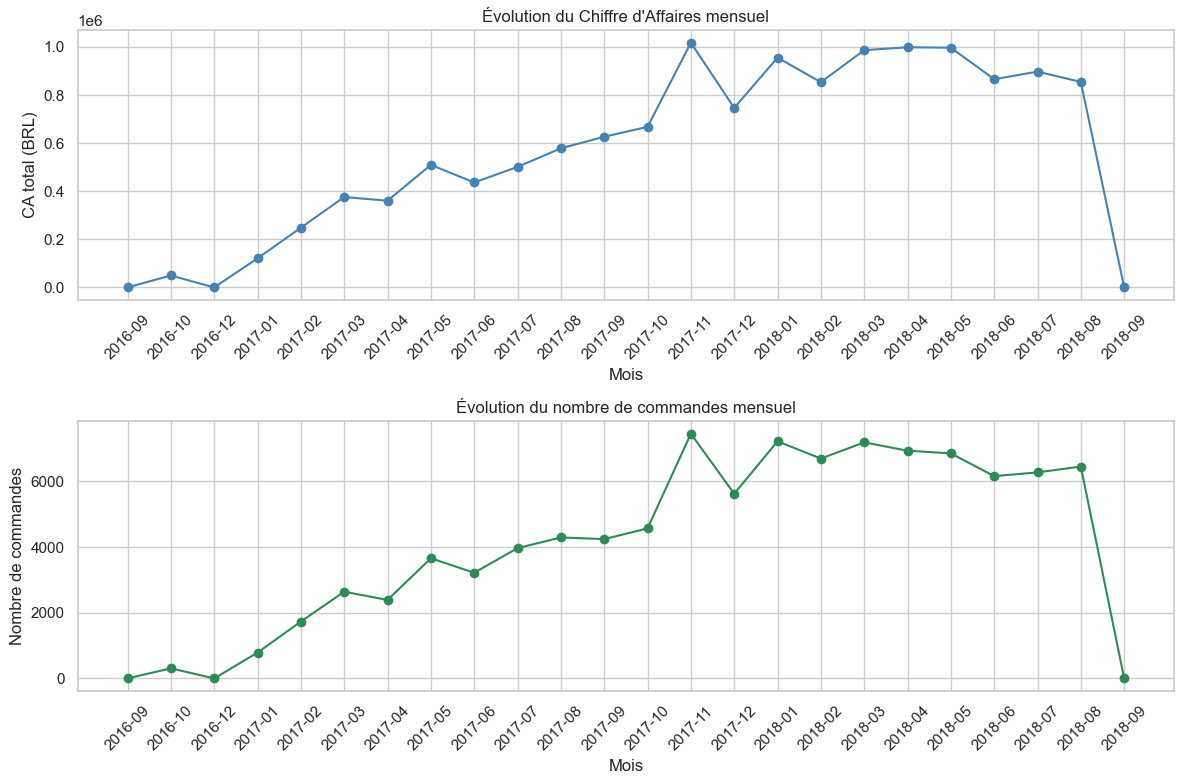

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Graphique 1 — CA mensuel
axes[0].plot(ca_mensuel['month'], ca_mensuel['ca_total'], 
             color='steelblue', marker='o')
axes[0].set_title("Évolution du Chiffre d'Affaires mensuel")
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("CA total (BRL)")
axes[0].tick_params(axis='x', rotation=45)

# Graphique 2 — Nombre de commandes
axes[1].plot(ca_mensuel['month'], ca_mensuel['nb_commandes'], 
             color='seagreen', marker='o')
axes[1].set_title("Évolution du nombre de commandes mensuel")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Nombre de commandes")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(r'C:\Users\HP\Desktop\projet_dataAnalyse\visuals\ca_mensuel.png', dpi=150)
plt.show()

### Réponse Question 8 — Évolution du CA mensuel

On observe une tendance générale à la hausse du chiffre d'affaires 
entre 2016 et 2018. Le CA passe de moins de 50 000 BRL en octobre 2016 
à près de 1 000 000 BRL en 2018.

On remarque un pic important en novembre 2017 (1 017 758 BRL) qui 
correspond probablement au Black Friday, période de forte activité 
commerciale au Brésil.

Le nombre de commandes suit la même tendance, ce qui confirme que 
la croissance du CA est liée à l'augmentation du volume de ventes 
et non uniquement à une hausse des prix.

  product_category_name_english    ca_total  nb_ventes
0                 health_beauty  1263138.54       9727
1                 watches_gifts  1206075.33       6001
2                bed_bath_table  1050936.61      11270
3                sports_leisure   993656.51       8700
4         computers_accessories   919640.54       7894
5               furniture_decor   736282.47       8415
6                    cool_stuff   637258.51       3806
7                    housewares   634542.60       6989
8                          auto   594363.10       4256
9                  garden_tools   486432.45       4361


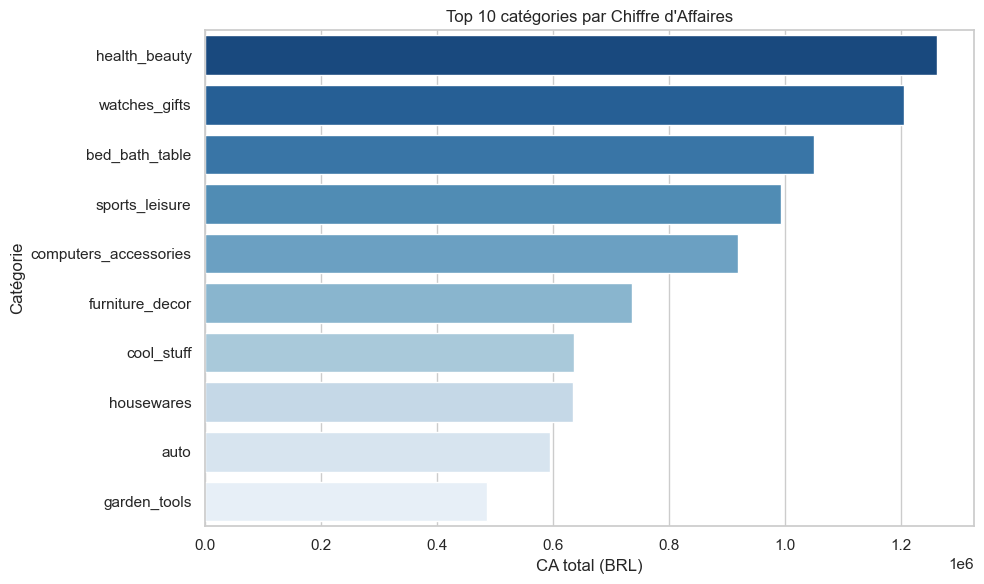

In [18]:
# Question 9 — Top catégories par CA
ca_cat = (
    df.groupby('product_category_name_english')
    .agg(ca_total=('price', 'sum'), 
         nb_ventes=('order_id', 'count'))
    .sort_values('ca_total', ascending=False)
    .reset_index()
)

print(ca_cat.head(10))

# Barplot des 10 meilleures catégories
plt.figure(figsize=(10, 6))
sns.barplot(data=ca_cat.head(10), 
            x='ca_total', 
            y='product_category_name_english',
            hue='product_category_name_english',
            legend=False,
            palette='Blues_r')
plt.title('Top 10 catégories par Chiffre d\'Affaires')
plt.xlabel('CA total (BRL)')
plt.ylabel('Catégorie')
plt.tight_layout()
plt.savefig(r'C:\Users\HP\Desktop\projet_dataAnalyse\visuals\top_categories.png', dpi=150)
plt.show()

### Réponse Question 9 — Top 10 catégories par CA

Les 3 catégories qui dominent en chiffre d'affaires sont :
1. health_beauty (1 263 138 BRL)
2. watches_gifts (1 206 075 BRL)
3. bed_bath_table (1 050 936 BRL)

On remarque que la catégorie la plus vendue en volume est 
bed_bath_table (11 270 ventes) mais elle n'est que 3ème en CA.
A l'inverse, watches_gifts est 2ème en CA mais seulement 6ème 
en volume (6 001 ventes).

Cela s'explique par le fait que les montres et cadeaux ont un 
prix unitaire plus élevé que les articles de maison, donc ils 
generent plus de CA avec moins de ventes.

In [ ]:
delai_etat = (
    df.groupby('customer_state')['delivery_days']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'delivery_days': 'delai_moyen_j'})
)

print("5 états les plus lents :")
print(delai_etat.head(5))
print("\n5 états les plus rapides :")
print(delai_etat.tail(5))

# Barplot des 10 états extrêmes
top5 = delai_etat.head(5)
bot5 = delai_etat.tail(5)
extremes = pd.concat([top5, bot5])

plt.figure(figsize=(10, 6))
sns.barplot(data=extremes,
            x='delai_moyen_j',
            y='customer_state',
            hue='customer_state',
            legend=False,
            palette='RdYlGn_r')
plt.title('Délai moyen de livraison par état (extrêmes)')
plt.xlabel('Délai moyen (jours)')
plt.ylabel('État brésilien')
plt.tight_layout()
plt.savefig(r'C:\Users\HP\Desktop\projet_dataAnalyse\visuals\delai_etat.png', dpi=150)
plt.show()

### Réponse Question 10 — Délai de livraison par état

Les 5 états les plus lents sont :
1. RR (Roraima) — 27.8 jours
2. AP (Amapá) — 27.8 jours
3. AM (Amazonas) — 25.9 jours
4. AL (Alagoas) — 24.0 jours
5. PA (Pará) — 23.3 jours

Les 5 états les plus rapides sont :
1. SP (São Paulo) — 8.3 jours
2. PR (Paraná) — 11.5 jours
3. MG (Minas Gerais) — 11.5 jours
4. DF (Distrito Federal) — 12.5 jours
5. SC (Santa Catarina) — 14.5 jours

Explication géographique : les états les plus lents comme RR, AP 
et AM sont situés dans le nord du Brésil, très éloignés des grands 
centres logistiques. Le Brésil est un pays immense et les 
infrastructures de transport dans le nord sont moins développées.

A l'inverse, SP (São Paulo) est la capi

In [ ]:
bins = [0, 7, 14, 21, 999]
labels = ['0-7j', '7-14j', '14-21j', '21j+']
df['delivery_bucket'] = pd.cut(df['delivery_days'], 
                                bins=bins, 
                                labels=labels)

satisfaction = (
    df.groupby('delivery_bucket', observed=True)['review_score']
    .mean()
    .reset_index()
)

print(satisfaction)

plt.figure(figsize=(8, 5))
sns.barplot(data=satisfaction,
            x='delivery_bucket',
            y='review_score',
            hue='delivery_bucket',
            legend=False,
            palette='RdYlGn_r')
plt.title('Note moyenne par tranche de délai de livraison')
plt.xlabel('Tranche de délai')
plt.ylabel('Note moyenne (1-5)')
plt.ylim(1, 5)
plt.tight_layout()
plt.savefig(r'C:\Users\HP\Desktop\projet_dataAnalyse\visuals\satisfaction_delai.png', dpi=150)
plt.show()

### Réponse Question 11 — Satisfaction client et délai de livraison

Les notes moyennes par tranche de délai sont :
- 0-7 jours : 4.33/5
- 7-14 jours : 4.20/5
- 14-21 jours : 4.02/5
- 21 jours et plus : 2.97/5

On observe une corrélation claire et négative entre la durée de 
livraison et la satisfaction client. Plus la livraison est rapide, 
plus la note est élevée.

La chute est particulièrement forte au-delà de 21 jours où la note 
moyenne tombe à 2.97/5, ce qui est en dessous de la moyenne.
Cela montre que les clients sont très sensibles aux longs délais 
de livraison et que reduire ces délais est un levier important 
pour améliorer la satisfaction client.

## Partie 4 — Visualisations Avancées & Synthèse

### Exercice 1 — Heatmap de corrélation

In [ ]:
corr_cols = ['price', 'freight_value', 'delivery_days', 'review_score']
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True)
plt.title('Matrice de corrélation — Variables clés')
plt.tight_layout()
plt.savefig(r'C:\Users\HP\Desktop\projet_dataAnalyse\visuals\heatmap_correlation.png', dpi=150)
plt.show()

print(corr)

### Réponse Question 12 — Analyse de la heatmap

La variable la plus corrélée à la note client (review_score) est 
delivery_days avec un coefficient de -0.30.

Le signe négatif confirme que plus le délai de livraison est long, 
plus la note client est basse. C'est cohérent avec les résultats 
de la Question 11.

La force de cette correlation (-0.30) est modérée mais significative 
sur un dataset de plus de 100 000 commandes.

Le prix (price) et les frais de port (freight_value) ont une 
correlation quasi nulle avec la note client (-0.004 et -0.036), 
ce qui signifie que les clients jugent principalement la qualite 
de la livraison et non le prix du produit.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution complète
sns.histplot(df['price'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution complete des prix')
axes[0].set_xlabel('Prix (BRL)')
axes[0].set_ylabel('Frequence')

# Distribution filtrée P95
p95 = df['price'].quantile(0.95)
sns.histplot(df[df['price'] < p95]['price'], kde=True,
             ax=axes[1], color='seagreen')
axes[1].set_title(f'Distribution filtree (< P95 = {p95:.0f} BRL)')
axes[1].set_xlabel('Prix (BRL)')
axes[1].set_ylabel('Frequence')

plt.tight_layout()
plt.savefig(r'C:\Users\HP\Desktop\projet_dataAnalyse\visuals\distribution_prix.png', dpi=150)
plt.show()

print(f"P95 = {p95:.2f} BRL")

### Réponse Question 13 — Distribution des prix

Le 95ème percentile est à 349.90 BRL, ce qui signifie que 95% 
des articles coutent moins de 350 BRL.

La distribution est fortement asymétrique à droite (right-skewed).
La majorité des articles ont un prix bas, mais quelques produits 
très chers tirent la distribution vers la droite.

Cela implique que la moyenne (120.65 BRL) n'est pas representative 
du prix typique car elle est influencée par ces valeurs extremes.
La médiane (74.99 BRL) est donc plus appropriée pour décrire 
le prix central des articles sur Olist.

Pour les analyses statistiques, il est préférable d'utiliser 
la médiane plutot que la moyenne, ou de filtrer les outliers 
comme nous l'avons fait avec le P95.

### Exercice 3 — Analyse libre : Mode de paiement et panier moyen

In [ ]:
paiement = (
    df.merge(payments[['order_id', 'payment_type', 'payment_value']], 
             on='order_id', how='left')
    .groupby('payment_type')
    .agg(nb_commandes=('order_id', 'nunique'),
         panier_moyen=('payment_value', 'mean'))
    .sort_values('nb_commandes', ascending=False)
    .reset_index()
)

print(paiement)

plt.figure(figsize=(8, 5))
sns.barplot(data=paiement,
            x='payment_type',
            y='nb_commandes',
            hue='payment_type',
            legend=False,
            palette='Blues_r')
plt.title('Nombre de commandes par mode de paiement')
plt.xlabel('Mode de paiement')
plt.ylabel('Nombre de commandes')
plt.tight_layout()
plt.savefig(r'C:\Users\HP\Desktop\projet_dataAnalyse\visuals\paiement.png', dpi=150)
plt.show()

### Réponse Exercice 3 — Mode de paiement et panier moyen

Le mode de paiement le plus utilisé est la carte de crédit 
(credit_card) avec 75 991 commandes, soit environ 75% des commandes.

Le boleto (equivalent du virement bancaire au Brésil) est le 
2ème mode de paiement avec 19 614 commandes.

En termes de panier moyen :
- Carte de crédit : 179.58 BRL
- Boleto : 177.41 BRL
- Carte de débit : 149.79 BRL
- Voucher : 64.62 BRL

Les vouchers ont un panier moyen tres faible (64.62 BRL) car 
ils sont souvent utilises pour des petits achats ou des reductions.
La carte de crédit domine à la

### Question 14 — Conclusion et recommandations

Les 3 principaux enseignements de cette analyse sont :

1. CROISSANCE FORTE : Le CA d Olist a connu une croissance 
   remarquable entre 2016 et 2018, avec un pic en novembre 2017 
   correspondant au Black Friday. Les categories health_beauty 
   et watches_gifts dominent en chiffre d affaires.

2. IMPACT DES DELAIS : Le délai de livraison est le principal 
   facteur influençant la satisfaction client. Les commandes 
   livrees en plus de 21 jours obtiennent une note moyenne de 
   2.97/5 contre 4.33/5 pour les livraisons en moins de 7 jours.
   Les états du nord (RR, AP, AM) souffrent de délais très longs.

3. PAIEMENT : La carte de crédit représente 75% des commandes 
   avec le panier moyen le plus élevé (179.58 BRL), ce qui en 
   fait le mode de paiement dominant sur la plateforme.

Recommandations pour l équipe produit Olist :

1. Reduire les délais de livraison dans les états du nord 
   (RR, AP, AM) en ouvrant des entrepôts regionaux ou en 
   négociant des partenariats logistiques locaux. Cela pourrait 
   significativement améliorer la satisfaction client dans 
   ces regions.

2. Capitaliser sur le Black Friday en anticipant les stocks 
   des categories health_beauty et watches_gifts, qui sont 
   les plus rentables, afin de maximiser le CA durant 
   cette période de forte demande.

In [19]:
df.to_csv(r'C:\Users\HP\Desktop\projet_dataAnalyse\data\processed\olist_df_processed.csv', 
          index=False)
print(f'Export OK — {df.shape[0]} lignes, {df.shape[1]} colonnes')

Export OK — 113314 lignes, 19 colonnes
